PROJECT: OIL WELL PRODUCTION OPTIMIZATION AND DRILLING EFFICIENCY VISUALIZATION

# INTRODUCTION

This project analyzes operational data from oil well drilling and production to identify optimization opportunities in drilling parameters and to elucidate the relationships between geological properties and drilling performance.  The project includes production and drilling logs, as well as a shapefile dataset that provides spatial information on well locations and regional boundaries.  This geospatial layer provides spatial context for drilling analysis, facilitating the integration of regional patterns, field boundaries, and location-based performance trends.  The integration of temporal, geological, and spatial data facilitates a thorough assessment of well performance and drilling efficiency over time and across different geographical contexts.These datasets were collected through standard industry monitoring systems during the operation of an onshore oil well. It consists of three main datasets which are listed below;

Oil Well Dataset: Time-series data of daily oil, liquid, gas volumes, water cut percentage, operating hours, dynamic level measurements, and reservoir pressure from 2013-2018

ROP Dataset: Includes rate of penetration, weight on bit, RPM, and geological data.

Geographic Data: Add spatial coordinates or regions (e.g., oil well locations) to enable geographic visualization through choropleth maps.


Source of Datasets:

- **ROP Dataset**: https://www.kaggle.com/datasets/ahmedelbashir99/drilling-log-dataset
- **Oil Well Production Dataset**: https://www.kaggle.com/datasets/ruslanzalevskikh/oil-well
- **Ontario Shapefile**: Downloaded from https://open.canada.ca/data/dataset/235fcd04-6632-4cce-a403-556089cc4276/resource/d5fbee67-c36a-4044-997d-ebe809a0073a

Code and Database Access
- This analysis requires Python notebook(jupyter notebook or Google Colab) with the following libraries installed and running: pandas, numpy, matplotlib, seaborn, plotly, scikit-learn, and geopandas.All files must be uploaded to the Colab environment before running this notebook. Datasets are loaded locally after downloading the dataset files(i.e csv,xlsx,SHP).


In [ ]:
!pip install ruptures

In [ ]:
!pip install contextily

LOAD LIBRARIES

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab" # Change the renderer to 'colab' for Google Colab environment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import geopandas as gpd
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import mean_squared_error, r2_score
import contextily as ctx
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# DATASET DETAILS

## 2.1 Preliminary Data Examination

For the oil well dataset contains 2,000 daily entries over five years with 9 variables tracking production and reservoir conditions. Initial cleaning involved handling missing dates and standardizing column names. while for the ROP dataset requires more deep preprocessing like:

- Sorting by depth
- Forward-filling missing values
- Merging with production data using date alignment.

while the ontario shapefile dataset contains over 10,000 wells with each geometry point each. The shapefile underwent some preprocessing like;

- filtered invalid geometrics
- view well type and geometry
- filter the 10 most common wells
- extract the longitude and latitude from the geometry

In [ ]:
# Load and clean oil well production data
oil_df_raw = pd.read_excel("/content/drive/MyDrive/dataset/Oil well.xlsx", skiprows=2)
oil_df_raw.columns = [
    "Date", "Oil_Volume_m3_day", "Liquid_Volume_m3_day", "Gas_Volume_m3_day",
    "Water_Volume_m3_day", "Water_Cut_percent", "Working_Hours",
    "Dynamic_Level_m", "Reservoir_Pressure_atm"
]
oil_df_raw.dropna(subset=["Date"], inplace=True)
oil_df_raw["Date"] = pd.to_datetime(oil_df_raw["Date"])

In [ ]:
# Load and preprocess ROP dataset
rop_df = pd.read_csv("/content/drive/MyDrive/dataset/ROP data .csv")
rop_df.sort_values("Depth", inplace=True)
rop_df.ffill(inplace=True)
rop_df["Depth_Diff"] = rop_df["Depth"].diff().fillna(0)
rop_df["ROP_m_per_day"] = rop_df["ROP_AVG"] * 86400
rop_df["Drilling_Time_Days"] = rop_df["Depth_Diff"] / rop_df["ROP_m_per_day"]
rop_df["Cumulative_Days"] = rop_df["Drilling_Time_Days"].cumsum().fillna(0).astype(int)
start_date = oil_df_raw["Date"].min()
rop_df["Date"] = start_date + pd.to_timedelta(rop_df["Cumulative_Days"], unit="D")
rop_daily = rop_df.groupby("Date").mean(numeric_only=True).reset_index()

In [ ]:
# Merge datasets using 'outer' to retain full oil dataset
merged_df = pd.merge(oil_df_raw, rop_daily, on="Date", how="outer")
merged_df.sort_values("Date", inplace=True)
merged_df.reset_index(drop=True, inplace=True)

merged_df.drop(columns=['Depth'], inplace=True, errors='ignore') # Rebuild Depth
merged_df = pd.merge(merged_df, rop_df[['Cumulative_Days', 'Depth']], on='Cumulative_Days', how='left')

In [ ]:
print(merged_df.head(100))

         Date  Oil_Volume_m3_day  Liquid_Volume_m3_day  Gas_Volume_m3_day  \
0  2013-01-01                 49                    70              13055   
1  2013-01-01                 49                    70              13055   
2  2013-01-01                 49                    70              13055   
3  2013-01-01                 49                    70              13055   
4  2013-01-01                 49                    70              13055   
..        ...                ...                   ...                ...   
95 2013-01-01                 49                    70              13055   
96 2013-01-01                 49                    70              13055   
97 2013-01-01                 49                    70              13055   
98 2013-01-01                 49                    70              13055   
99 2013-01-01                 49                    70              13055   

    Water_Volume_m3_day  Water_Cut_percent  Working_Hours  Dynamic_Level_m 

In [ ]:
print(oil_df_raw.head(2000))
print(rop_daily.head(2000))

           Date  Oil_Volume_m3_day  Liquid_Volume_m3_day  Gas_Volume_m3_day  \
0    2013-01-01                 49                    70              13055   
1    2013-01-02                 49                    70              13055   
2    2013-01-03                 49                    70              13055   
3    2013-01-04                 49                    70              13055   
4    2013-01-05                 44                    70              11768   
...         ...                ...                   ...                ...   
1995 2018-06-20                 12                    60               3152   
1996 2018-06-21                 12                    60               3152   
1997 2018-06-22                 13                    59               3392   
1998 2018-06-23                 13                    59               3546   
1999 2018-06-24                 12                    51               3103   

      Water_Volume_m3_day  Water_Cut_percent  Worki

## 2.2 Munzner WHAT Analysis

### Data Types
- **Tables**: The ROP and oil production datasets are tabular, while the shapefile is spatial-vector based
  - **Oil Well Production**: A multidimensional time-series Data
  - **ROP Data**: Multidimensional table with continuous variables
  - **Ontario Shapefile**: Geospatial dataset with well metadata (WELL_TYPE, geometry)
### Attribute Types
- **Categorical**:
  - WELL_TYPE
  - Cluster
  - Well_Pad
  - WELL_TYPE

- **Ordered**:
  - Date
  - Depth
  - Cumulative_Days

- **Quantitative**:
  - Oil_Volume_m3_day [ m³/day]
  - Liquid_Volume_m3_day [ m³/day]
  - Gas_Volume_m3_day [ m³/day]
  - Water_Cut_percent [%]
  - Dynamic_Level_m [ m]
  - Reservoir_Pressure_atm [ atm]
  - WOB [ units]
  - SURF_RPM
  - ROP_AVG [ units/time]
  - PHIF (Porosity Factor)
  - VSH (Shale Volume)
  - KLOGH (Permeability)

- **Spatial**:
  - Geometry
  - longitude
  - latitude

- **Temporal**:
  - Date
  - Cummulative_days

**Dataset Availability**: the datasets are static(historical or archive-based) and they exists in multiple formats like CSV(tabular),XLSX(tabular), shapefile(SHP/DBF/PRJ). Two related data sources joined on Date

- **Alternative Classification**
  - PHIF - Temporal(time-laspe logging)
  - WELL_PAD - Spatial
  - WELL_TYPE - Temporal
  - Latitude - Quantitative
  - Longitude - Quantitative



# PROJECT GOALS AND OBJECTIVES

## 3.1  Questions
- Can spatial clustering reveal useful patterns for well placement strategy?
- What combinations of geological and operational features predict efficient drilling?
- How are petroleum well types geographically distributed across Ontario, and what spatial insights can we gain about drilling focus and field development patterns?
- How do drilling conditions vary across formations, and how can visual analytics improve operational decision-making?
- Could interactive visualizations support real-time ROP prediction or bit selection?
- How do production patterns (oil, gas, water) evolve over time?
- Can we detect structural breaks or operational shifts?
- What combinations of drilling parameters define distinct cluster behaviors?
- How are petroleum well types geographically distributed across Ontario, and what spatial insights can we gain about drilling focus and field development patterns?
- How do correlations between drilling parameters evolve with depth, and do deeper zones exhibit different drilling dynamics?
- What spatial distribution patterns emerge from cluster assignments?
- What types of drilling strategies exist in our dataset, and how do operational variables differ across those strategies?"


## 3.2 Munzner WHY Analysis

SPECIFIC QUESTIONS
- How do oil, water, and gas production volumes evolve over time, and can we monitor their decline or operational changes through visual patterns?
- What types of drilling strategies exist in our dataset, and how do operational variables differ across those strategies?
- How do correlations between drilling parameters evolve with depth, and do deeper zones exhibit different drilling dynamics?
- How are petroleum well types geographically distributed across Ontario, and what spatial insights can we gain about drilling focus and field development patterns?
- How are petroleum well types geographically distributed across Ontario, and what spatial insights can we gain about drilling focus and field development patterns?

### Question1:
**"How do oil, water, and gas production volumes evolve over time, and can we monitor their decline or operational changes through visual patterns?"**

the question was answered by using This plot which aligns with multiple production metrics with varying magnitudes on a shared time axis to detect production behavior over time. Dual y-axes are used to scale variables like gas and oil production in tandem.

#### **Analyze**
- **Action**: Visually inspect multi-year trends in production behavior.
- **Target**: Temporal sequences of quantitative attributes (Oil, Water, Gas).
- **Purpose**: Detect operational shifts, performance decline, or maintenance cycles.

  **Observation**:
Oil production experiences a consistent decline over the years. Gas exhibits elevated yet erratic patterns. The water cut stabilizes during the later stages of production.



#### **Compare**
- **Action**: Contrast volumes with different scales across time.
- **Target**: Normalized dual y-axis values.
- **Purpose**: Interpret simultaneous trends across production streams.

  **Observation**:
Although gas operates on a larger scale, its decline parallels the directional trend observed in oil. The visual scale aids in the identification of imbalances or deficiencies in recovery progress.



#### **Query**
- **Action**: Identify specific value trends for annotated events.
- **Target**: Production line markers.
- **Purpose**: Determine if interventions (workover, fracking) aligned with production rebound.

  **Observation**:
Sudden water spikes in some months may signal mechanical influx or injection support.










### Question2:
**"What types of drilling strategies exist in our dataset, and how do operational variables differ across those strategies?"**

The radar chart helps answers this question employing KMeans clustering to categorize drilling behavior based on five normalized variables: ROP, RPM, WOB, PHIF, and VSH.  Each cluster is depicted as a polygon, characterized by its distinct profile.



#### **Summarize**
- **Action**: Reduce dimensionality into high-level cluster patterns.
- **Target**: Feature combinations per cluster.
- **Purpose**: Identify signature operational modes.

  **Observation**:
  - Cluster 0 = Balanced drilling.
  - Cluster 1 = High WOB & ROP (aggressive).
  - Cluster 2 = High RPM & shale (precision or exploratory).



#### **Compare**
- **Action**: Contrast average normalized values between clusters.
- **Target**: Polygon radii in radial layout.
- **Purpose**: Detect outliers or optimized modes.

  **Observation**:
Cluster 1 exhibits dominance in WOB and ROP, yet shows a decline in PHIF. The pronounced shale signature of Cluster 2 renders it geologically distinct.



#### **Explore**
- **Action**: Visually examine variance across all five dimensions.
- **Target**: Multivariate shapes.
- **Purpose**: Uncover possible physical-geological influences.

  **Observation**:
RPM values remain modest for most clusters—bit aggressiveness varies.

### Question3:
"How are petroleum well types geographically distributed across Ontario, and what spatial insights can we gain about drilling focus and field development patterns?"

This question was answered with the help of a live choropleth that plots different types of wells from real government shapefile data onto a map of Ontario.  Each well is colored by its {WELL_TYPE}, and spatial plotting lets users see right away whether digging activities are grouped together or spread out.  It shows on a regional level where different types of wells (oil, gas, dry holes, etc.) are most common, which lets researchers look into drilling trends that are caused by geology, the economy, or government policy.

#### **Analyze**
- **Action**: Visually analyze spatial distribution of well types.
- **Target**: Categorical WELL_TYPE plotted as geographic points.
- **Purpose**: Discover large-scale patterns such as resource-rich zones or historical drilling focus.

**Observation**:
Oil Well and Gas Show kinds are quite common in southern Ontario.  Less active areas have scattered Dry Hole and Historical Oil Well types.



#### **Search**
- **Action**: Search for geographic clusters or isolated well types.
- **Target**: Locations with high density of specific types (e.g., Stratigraphic Test, Natural Gas Well)
- **Purpose**: Investigate spatial uniformity or anomalies in drilling strategy.

**Observation**:
Certain areas exhibit significant dominance of a singular type, such as a high concentration of oil wells near Lake Erie.  Stratigraphic test wells are located at the peripheries, indicating their use for exploration.



#### **Query**
- **Action**: Hover over points to get interactive metadata (well type, coordinates).
- **Target**: Individual wells with rich attribute information.
- **Purpose**: Drill down into local features or specific well cases for inspection.

**Observation**:
Compressed air energy storage wells are the odd or outlier sorts that can be revealed by clicking on the points.  The location of latitude and longitude verifies that the geometry in the shapefile is accurate.

# INITIAL DATA ANALYSIS


In [ ]:
# descriptive statistics for columns
stats_summary = merged_df.describe()
print("Statistics Summary:\n", stats_summary)

Statistics Summary:
                                 Date  Oil_Volume_m3_day  Liquid_Volume_m3_day  \
count                           3088        3088.000000           3088.000000   
mean   2016-10-30 19:04:49.119170816          19.138277             59.972474   
min              2013-01-01 00:00:00           0.000000             12.000000   
25%              2014-09-15 18:00:00          12.000000             51.000000   
50%              2016-10-27 12:00:00          15.000000             59.000000   
75%              2018-12-08 06:00:00          24.000000             73.000000   
max              2021-01-18 00:00:00          49.000000            113.000000   
std                              NaN          11.600380             18.318553   

       Gas_Volume_m3_day  Water_Volume_m3_day  Water_Cut_percent  \
count        3088.000000          3088.000000        3088.000000   
mean         5131.831282            40.823834          68.682966   
min             4.000000             9.000000

In [ ]:
x = rop_df.drop(columns=['ROP_AVG', 'ROP_m_per_day', 'Drilling_Time_Days'])# define your predictor(independent) variables of X, this is all the features expect the target variable
y = rop_df['ROP_AVG']# define your regressor(dependent)variables of y, this is the target variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=62) # we use this function to split the Drill_data into training and testing sets

In [ ]:
# Select only numeric features for scaling
numerical_features = x.select_dtypes(include=np.number).columns
X_train_numeric = X_train[numerical_features]
X_test_numeric = X_test[numerical_features]

scaler = StandardScaler() # Apply scaling to the numeric features
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_features, index=X_train.index)
X_train = pd.concat([X_train_scaled, X_train.drop(columns=numerical_features)], axis=1)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_features, index=X_test.index)
X_test = pd.concat([X_test_scaled, X_test.drop(columns=numerical_features)], axis=1)

In [ ]:
regressor = DecisionTreeRegressor(max_depth=3)
regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled) # #To train the model on the test set

mse = mean_squared_error(y_test, y_pred) # to Evaluate the model predictions and performance
r2 = r2_score(y_test, y_pred) # To Evaluate the variance of the model

print(f"Mean Squared Error: {mse}") # print out the MSE
print(f"R-squared: {r2}") # print out the variance

Mean Squared Error: 1.3919304551667558e-06
R-squared: 0.4713151119154648


From our MSE: 1.3919304551667558e-06,This shows how accurate the predictions from our model is, we can say that from the value above our model makes accurate predictions. From our R2:0.4713151119154648 is shown that our model is good,but it can be improved

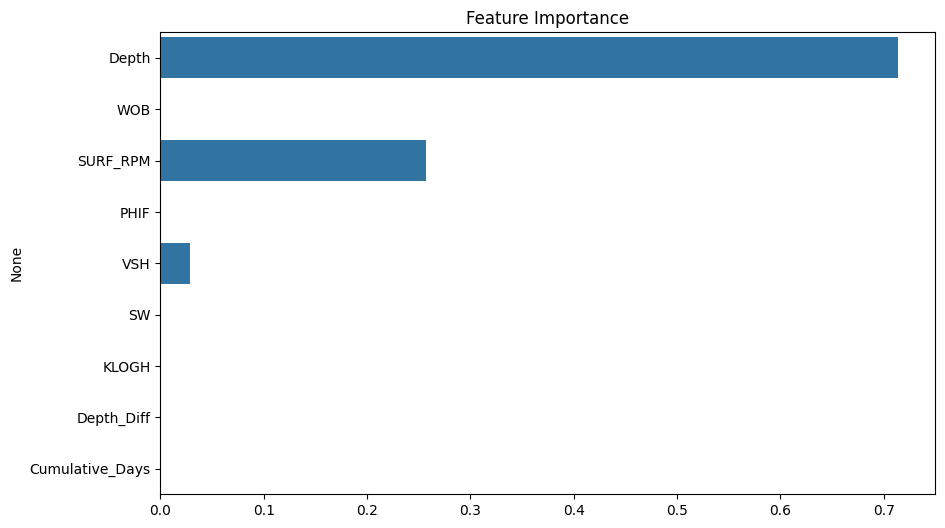

In [ ]:
feature_importances = regressor.feature_importances_

feature_names = X_train_scaled.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.title('Feature Importance')
plt.show()

From the feature_importance we found out that the most important feature affecting our target variable is the Depth(Depth of the well) followed by the surface rotation per minute(SURF_RPM) and volume of shale(VSH). While the other features has the least effects.

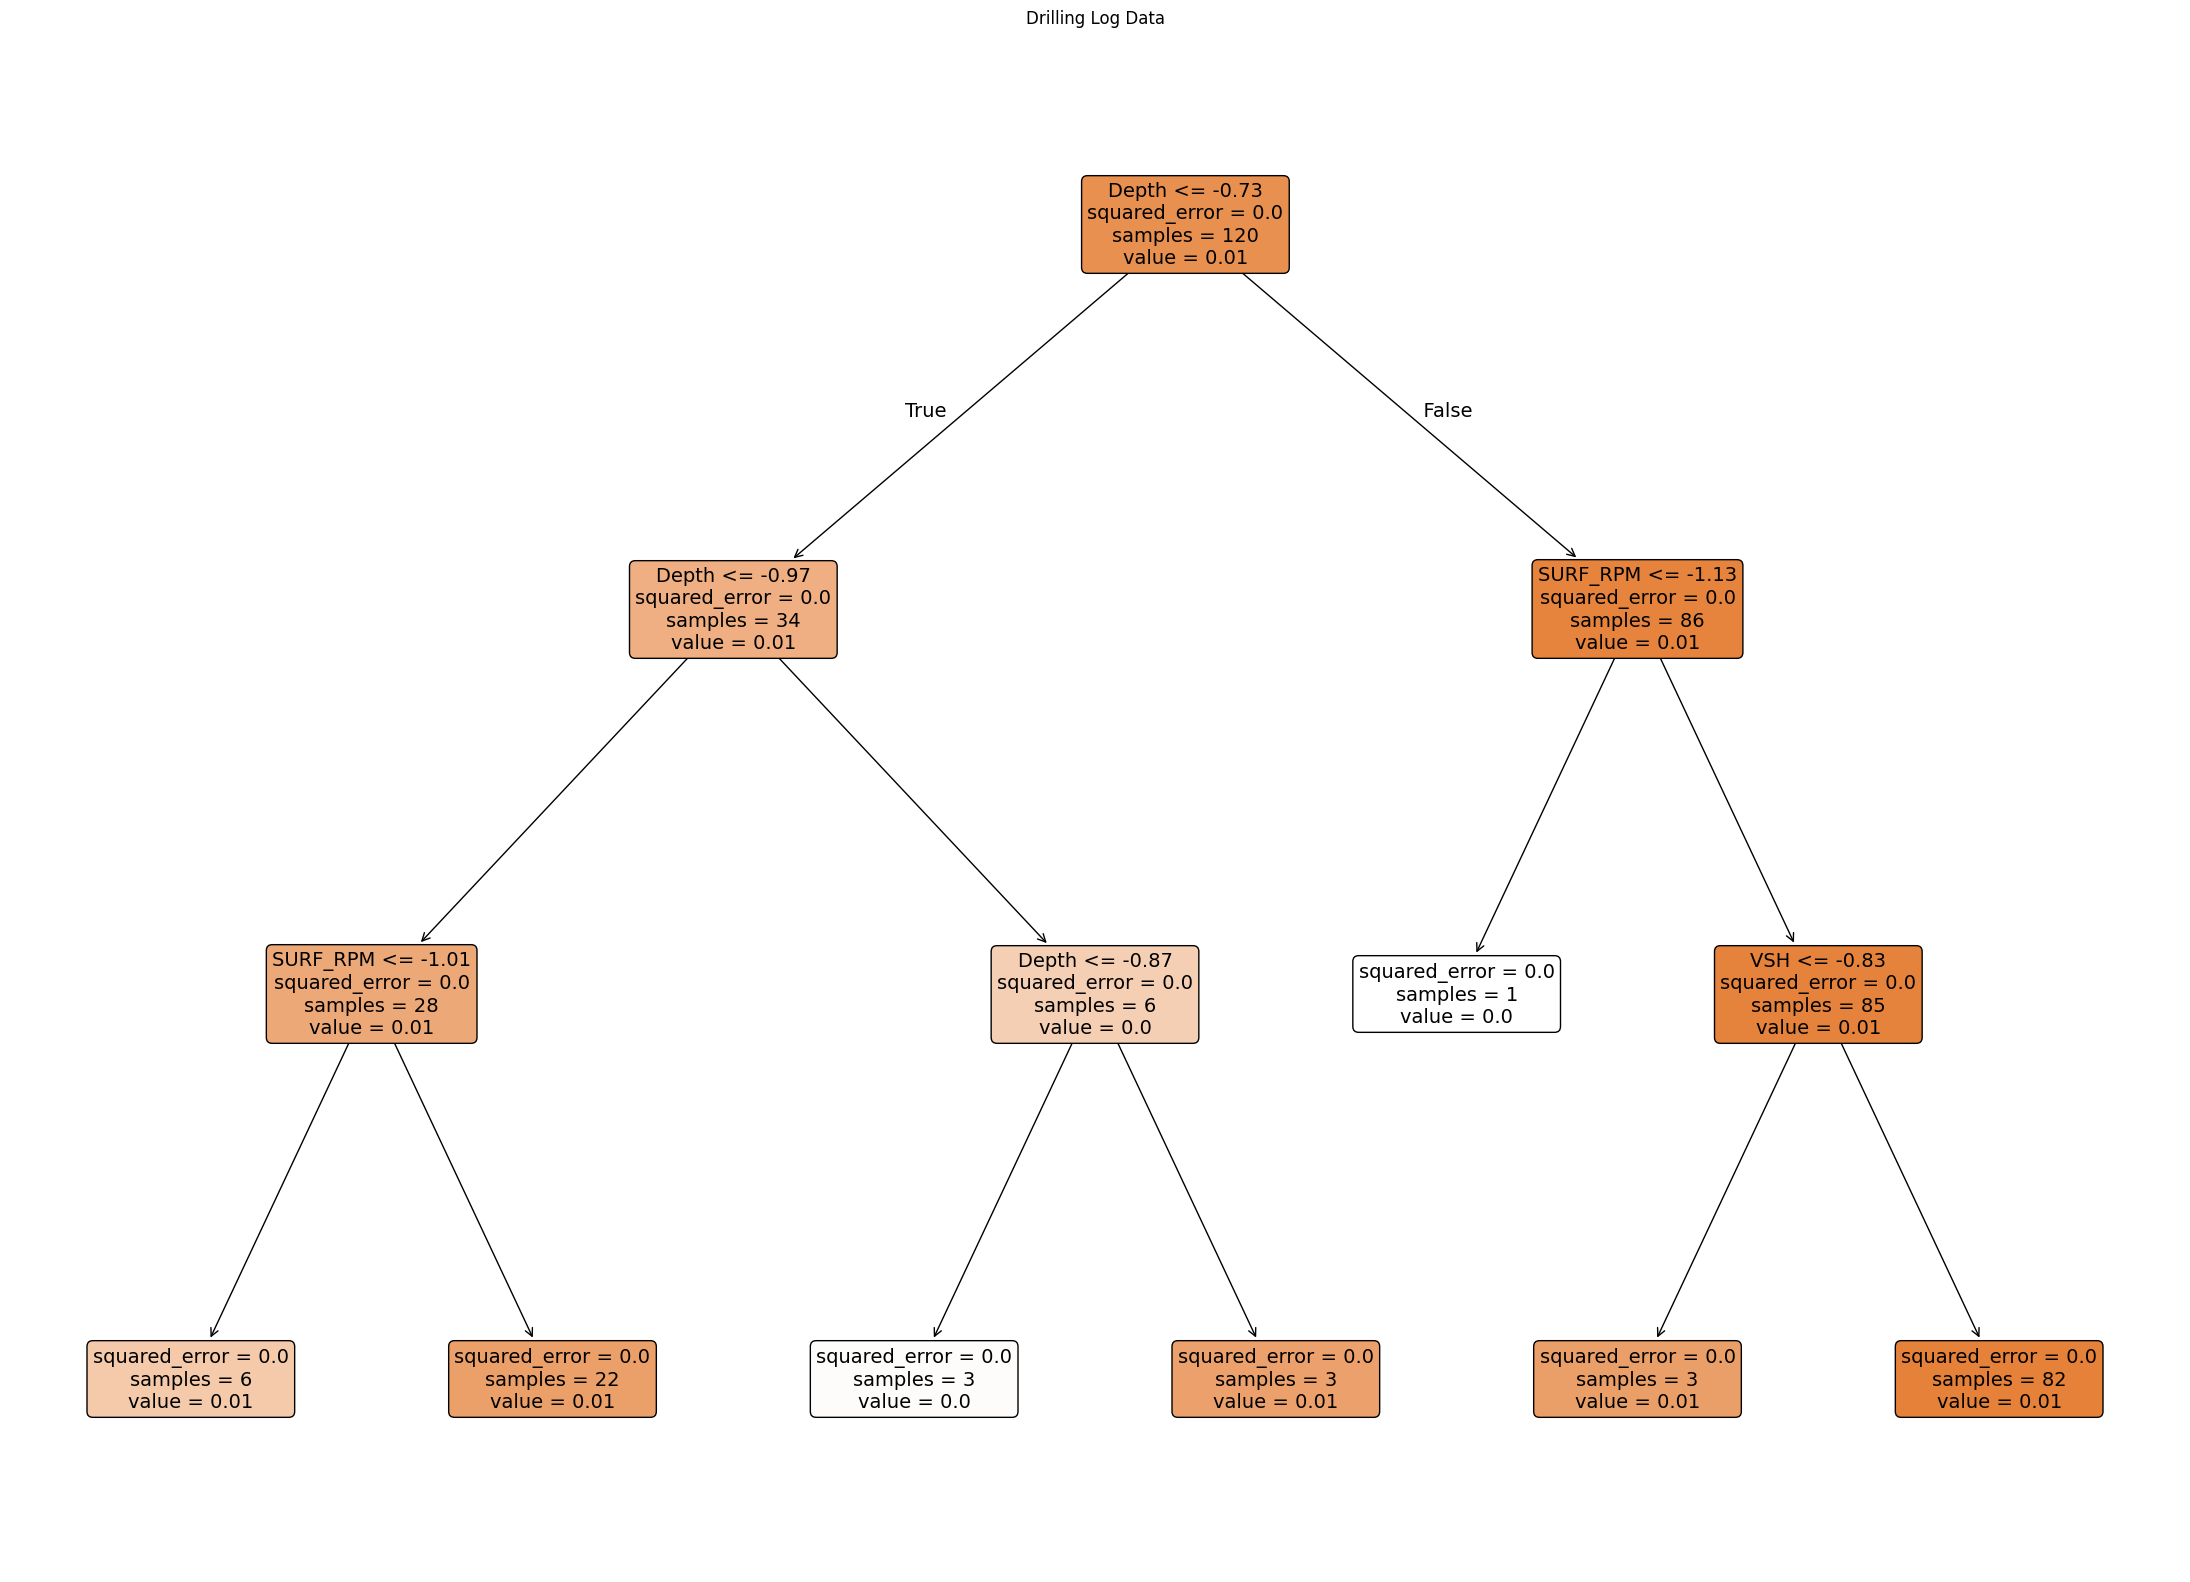

In [ ]:
from sklearn.tree import plot_tree # Import the plot_tree function
import matplotlib.pyplot as plt

plt.figure(figsize=(28,20)) # Plot the decision tree to have a clear visualization of the tree, choose this particular dimensions inorder to see the result of our decision tree more clearly
tree_plot = plot_tree(regressor, filled=True, feature_names=x.columns, rounded=True, precision=2, fontsize=14) # use x.columns here as X_train is now a numpy array after scaling and does not have the attribute 'columns'
plt.title("Drilling Log Data") # name of the decision tree
plt.show()

The Decision tree is basically answering yes or no question to make prediction about the Rate of pentration(ROP_AVG).from our decision tree we notice the root node(the first block of the tree) started from the depth,this tells us that depth is one of the most important feature on the decision tree. The Decision tree continues to split the data based on other features.Each node is making a decision that solit the dataset into more specific group, trying to predict the Rate of penetration(ROP_AVG) at the end of the day. If you notice at the end of the decision tree(the leaf node) it predicted different Rate of pentration based on different paths(features) the model followed.

In summary, the decision tree helps predicts the rate of pentration(ROP_AVG) based on the features from the drilling log data such as depth of the well,weight on the bit, rotation per minute, porosity, volume of shale and others.

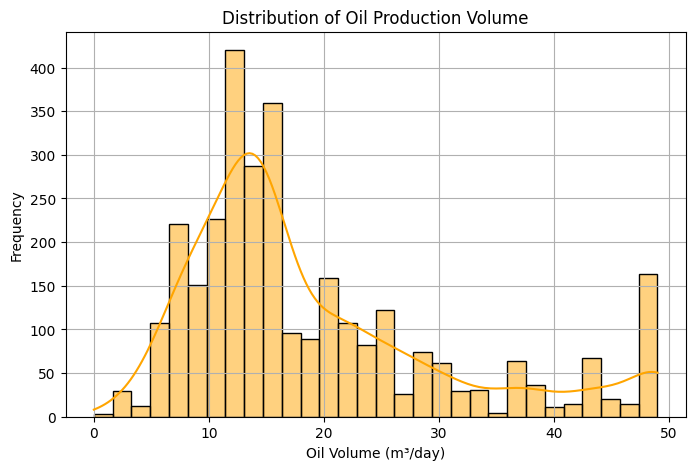

In [ ]:
# Histogram distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(merged_df['Oil_Volume_m3_day'].dropna(), kde=True, bins=30, color='orange')
plt.title('Distribution of Oil Production Volume')
plt.xlabel('Oil Volume (m³/day)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


This histogram indicates that most oil production values fall between 10 and 20 m³/day, suggesting a typical moderate-output performance for the wells. While a small number produce very little, there's a right-skewed tail indicating less wells producing high production (30–50 m³/day). Several peaks indicate operational or geological variation, perhaps caused by different well conditions or reservoir zones. All things considered, the distribution shows a varied spectrum of output throughout the field.

# Visualization Design Choices



#  First Visualization : Multi-Axis Time Series Plot(1)

**INSPIRATIONS DESIGNS AND SOURCES**

This design was inspired by real-world SCADA dashboards used in oilfield operations to monitor multiphase production (oil, gas, water) simultaneously. These systems often visualize production rates using time-series plots with multiple axes to manage differences in scale, similar to the approach discussed in Munzner’s visual idiom of aligned temporal data.

**IDIOMS & MARKS**
- **Idioms**:

 - Line chart: Used to represent trends overtime for oil volume, water volume, gas volume. this helps us to show continous the data is and identify fluctuation.
 - Dual Y-axis: This helps us to simultaneously visualize the data, since it has different scales
 - Color coding: Different colours are applied to differentiate the vaariables(oil, water and gas)

- **Marks**:

 - Points: Data points are plotted to represent specific values for oil, water and gas.
 - Line: Continous lines to connect the data points for oil, water and gas.
 - Axes: The x-axis marks time (Date), while the y-axes mark production volumes (Oil/Water on the left and Gas on the right)
 - Legends: used to indicate the colour code representation of each variable

- **Channels:**
  - Position: Time mapped on x-axis, volume on y-axes.
  - Color: Different colors are used to distinguish the variables.
  - Size: Appropriate thickness of the lines for a clear plot to avoid confusion
  - Orientation: Landscape orientation provide a clear spatial relationship between time and production volumes.
  - legends: Used to link colour to each of their variable(oil,gas and water)

## GOALS

Summarize production patterns over time for multiple fluid types (oil, gas and water)

**Questions Answered:**
  - How do oil, water, and gas production evolve over time?
  - Are changes in water cut or gas production associated with oil decline?
  - Are there coordinated trends between oil, water, and gas outputs?

**Action/Target Pairs:**
  - Analyze: Trends (track production variations)
  - Compare: Features (identify divergence in behavior)
  - Summarize: Time-aligned multivariate patterns  

**HOW TECHNIQUES AND METHOD**

The graph shows Oil, Water, and Gas production volumes throughout time using multiple methods.  It plots 2013–2021 data using time series visualization, making it excellent for tracking changes and trends.  The chart uses a dual y-axis, with the left axis indicating Oil and Water Volumes (m³/day) and the right axis showing Gas Volume.  This approach displays variables with multiple scales simultaneously.  To simplify identification, oil, water, and gas are colored blue, orange, and green, respectively.  Line charts, where continuous lines connect data points, show trends and fluctuations.  The continuous lines indicate data smoothing to accentuate trends while plotting raw data values.

 The graph uses visual encoding to describe data utilizing channels like position (x-axis for time; y-axes for volumes), color (to separate variables), and line thickness.  The dual y-axis scales variables with dramatically different magnitudes (e.g., oil vs. gas volumes) for comparison.  The graph helps identify trends like diminishing oil and gas output and variable water production.  It helps discover anomalies by showing water and gas volume surges, encouraging additional research into operational or environmental factors.  Finally, a legend integration links colors to variables for clear interpretation.  These tools and methodologies make the graph useful for understanding production trends.




OTHER INSPIRATIONS/NON-MUNZER METHODOLOGY AND GUIDANCE APPLIED

The graph uses a number of well-known visual concepts to show, explain, and talk about trends over time.   As is the case with time-series representation, line charts are used to show changes and trends over time.   The x-axis shows time (Date), which makes it easy to look at data in order, and the points that are connected to each other continuously show how production amount changes over time.   Second, the graph has two y-axes that show variables with very different sizes, like Oil/Water Volumes vs. Gas Volumes, without losing any information.   So that people can tell them apart in the shared area, the variables are colored blue for oil, orange for water, and green for gas.

The design is based on Gestalt ideas like closeness and continuity.   People can understand trends in oil, water, and gas production better with close lines. Smooth lines, on the other hand, draw the viewer's attention along the trends and reinforce patterns over time.   Position encoding on the y-axes correctly shows production volumes, and color differentiation encodes categorical data.   A clear legend connects colors to factors so that they are easy to understand.

The graph also shows changes and spikes in the volumes of water and gas, which helps users find things that don't seem right and may need more research.   Lastly, to keep things simple, only the most important parts are used, like lines, axes, titles, and a legend.   This method is based on Edward Tufte's "data-ink ratio," which says that data should be given more weight than design elements.   These rules make the graph useful, appealing, and good at showing how production has changed over time.

**Alternative Visualization**

Other Plots for visualizing time-series data include stacked area charts, bar charts, Season plots, stream graph, Seasonal subseries plot, Gantt chart and polar area diagrams. While these alternatives can be effective in specific contexts (e.g., showing cumulative totals or cyclical patterns), they were not chosen here due to their limitations in representing simultaneous trends across multiple independent variables



**COMMENTARY:**
- **Success critique:** Clearly conveys production fluctuations and correlation between fluids.
- **Utility:**
  - Effective for monitoring operational trends across multi-phase outputs.
  - It serves as a valuable tool for decision-makers in resource management, maintenance planning, and optimization efforts

- **Improvement Suggestion:**
  - Annotate major changes (e.g., interventions, equipment changes) for context.
  - incorporation interactive features
  - using of dash or dotted lines to help in the differentation of oil, gas and water

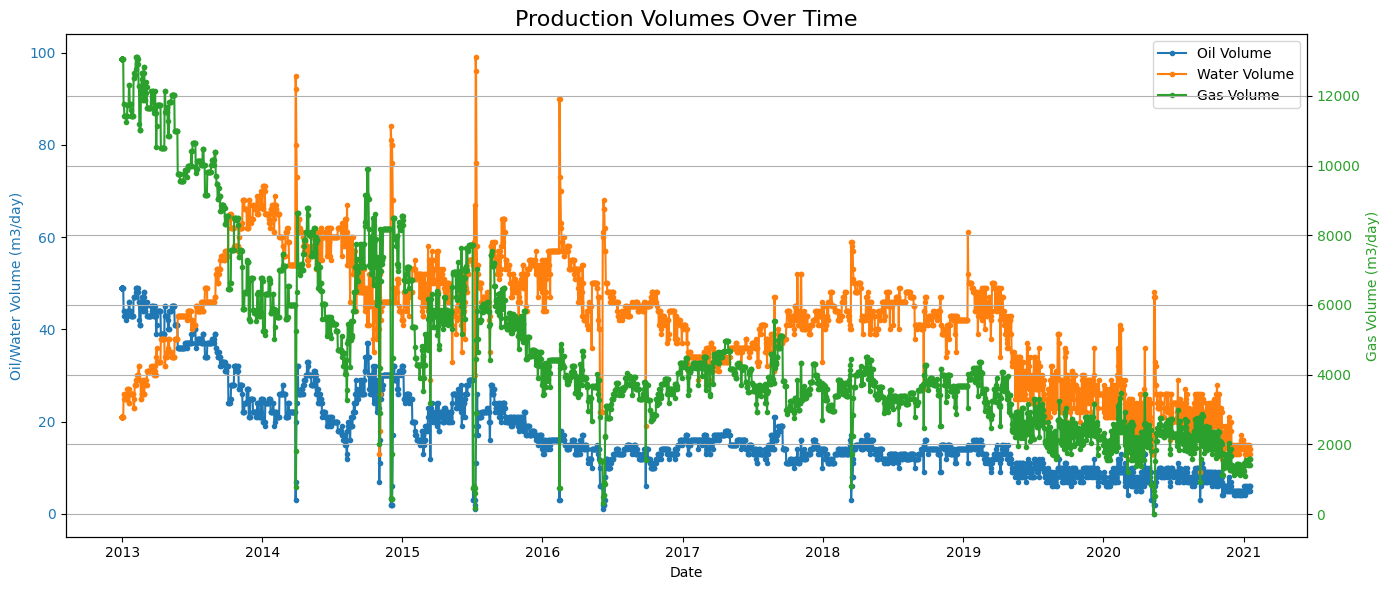

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Use markers to improve visibility of sparse data
marker_style = dict(marker='o', markersize=3)

# Primary Y-axis for oil and water
ax1.set_title("Production Volumes Over Time", fontsize=16)
ax1.set_xlabel("Date")
ax1.set_ylabel("Oil/Water Volume (m3/day)", color="tab:blue")
ax1.plot(merged_df['Date'], merged_df['Oil_Volume_m3_day'], label='Oil Volume', color="tab:blue", **marker_style)
ax1.plot(merged_df['Date'], merged_df['Water_Volume_m3_day'], label='Water Volume', color="tab:orange", **marker_style)
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Secondary Y-axis for gas
ax2 = ax1.twinx()
ax2.set_ylabel("Gas Volume (m3/day)", color="tab:green")
ax2.plot(merged_df['Date'], merged_df['Gas_Volume_m3_day'], label='Gas Volume', color="tab:green", **marker_style)
ax2.tick_params(axis='y', labelcolor="tab:green")

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**: This section provides a time-series visualization of production volumes (oil, water, gas).Because gas volume is much higher than oil and water, we use two Y-axes to avoid visual distortion. This makes oil and water variations more visible while still displaying gas trends accurately.

**JUSTIFICATION:** This line chart visualizes oil, gas, and water volumes over time. It was chosen to show the interplay between production components and how they evolve. Oil and water plotted on left y-axis; gas plotted on right y-axis. Color hue distinguishes variables. lines connect daily measurements.

# EXTRA VISUALIZATION: Change Point Detection

INSPIRATIONS DESIGNS AND SOURCES

Inspired by industrial time-series anomaly detection used in predictive maintenance systems, particularly those found in oil & gas pipeline monitoring, manufacturing sensors, and financial systems. Methodology includes ruptures package and domain logic for penalty selection.Visual design was influenced by time-series diagnostic plots used in fields like: Predictive maintenance dashboards like Siemens, GE APM, Reservoir surveillance graphs that track production anomalies and Online monitoring tools for detecting regime shifts in operations

IDIOMS $ MARKS



- **Idioms**
  - Change Point Detection: used to highlight significant shifts in oil production trends over time.
  - Smoothed Signal: The blue line represents a smoothed signal, which serves to minimize noise and highlight underlying trends in the data, whereas the gray line reflects the original signal, preserving its inherent variability.
  - Time series analysis: The idiom of plotting data against time on the x-axis
- **Mark**
  - **Lines**:One-dimensional line marks are used to show both the original and smoothed signals. These marks are good for showing continuous data changes over time.
  - **Vertical lines**:Red dashed lines serve as marks to emphasize specific points (i.e.change points) on the timeline.
- **Channel**
  - Position: The x-axis encodes time, while the y-axis encodes oil volume (m³/day)
  - colour: Different colors help distinguish between data types and annotations
  - Length: The length of the blue line visually represents the duration of oil production trends.
  - Dash Pattern: The dashed form of the red lines makes them even more noticeable, making transition points easier to spot.

 Goals

Identify Breakpoints in oil production behavior

**Questions Answered:**
  - When do shifts in oil production occur?
  - How abrupt or gradual are those transitions?


 **Action/Target Pairs:**
  - Identify: Regime changes
  - Analyze: Shifts in trend
  - commpare: Raw data (gray line) versus smoothed data (blue line).

**HOW TECHNIQUES AND METHODS**

The visualization looks at oil production data on oil output and shows it in two different ways.   Finding the Change Points in a Time Series   When you smooth data, you can see long-term patterns and big changes.

Change Point Detection finds times when important data factors change a lot.   Statistical algorithms divide time series into similar periods to find changes in mean, variance, and slope.   These pieces show changes in the production that were made.   Trends in oil supply change at key points, which are shown by red dashed vertical lines.   This approach lets us figure out whether problems within the company or problems in the outside world are holding back productivity.






**OTHER INSPIRATIONS/NON-MUNZER METHODOLOGY AND GUIDANCE APPLIED**

The Second visualization Change Point Detection on Smoothed Oil Production Signal uses multiple methods beyond Munzner's framework for a complete analytical tool.  Blue smoothed lines for trends, gray original signals for context, and red dashed lines for crucial change points with visual salience follow Cleveland and McGill's expressiveness and effectiveness principles.  Gestalt principles improve clarity through smoothed blue line continuity, time-point-production change connections, and figure-ground linkages that highlight significant data pieces against the backdrop grid.  Statistical methods for change point detection split data into discrete periods, pinpointing exact production regime transitions, while smoothing methods decrease noise and preserve relevant patterns, making complex time-series data more interpretable.  Blue, gray, and red colors and dashed patterns help users with color differentiation.  Finally, iterative visualization design concepts link statistical methods and visual encodings with oil production trend analysis.  Statistical rigor and perceptual design principles generate a visualization that exceeds established frameworks to better represent oil production data.

**Alternative Visualization**

Other plots for visualizing includes layered area chart, heatmap representation, interactive Dashboard, animated charts, network-based e.t.c. As alternative can be effective, it can detect more subtle changes than produces fewer false. It also tracks where the precise values and trend changes.

**COMMENTARY**:

- Success critique: Highlights production phase transitions cleanly.The visualization successfully conveys key insights into oil production trends over time.The plot is well-labeled, with clear axes (time and oil volume) and a legend differentiating the original and smoothed signals.

- Utility:

  - It enables quick identification of periods of stability and abrupt changes.
  - detecting significant moments of change while maintaining an overall view of production trends.
  
- Improvement Suggestion:

  - Add labels or annotations for each change point.
  - incorporation interactive features.
  - Ensure that the chosen colors (gray, blue, red) are accessible for colorblind users by incorporating alternative visual cues like varying line thickness or patterns.

In [ ]:
print("Oil Volume Description:") # Inspect oil volume variability
print(merged_df['Oil_Volume_m3_day'].describe())

Oil Volume Description:
count    3088.000000
mean       19.138277
std        11.600380
min         0.000000
25%        12.000000
50%        15.000000
75%        24.000000
max        49.000000
Name: Oil_Volume_m3_day, dtype: float64


<ipython-input-45-972181fd0ad4>:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



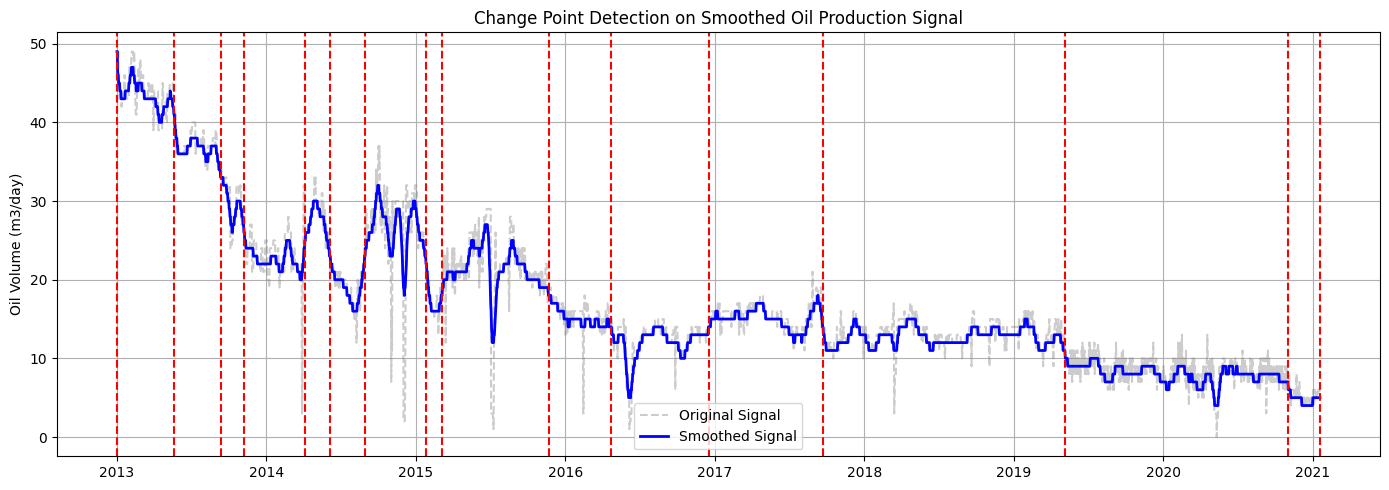

In [ ]:
# Smooth the signal to reduce noise and enhance change detection
signal = merged_df['Oil_Volume_m3_day'].fillna(method='ffill').values
signal_smoothed = gaussian_filter1d(signal, sigma=5)

model = rpt.Pelt(model="rbf").fit(signal_smoothed)
change_points = model.predict(pen=10)  # lower penalty for sensitivity

# Plot original vs smoothed signal with change points
plt.figure(figsize=(14, 5))
plt.plot(merged_df['Date'], signal, label='Original Signal', linestyle='--', alpha=0.4, color='gray')
plt.plot(merged_df['Date'], signal_smoothed, label='Smoothed Signal', color='blue', linewidth=2)
for cp in change_points:
    plt.axvline(merged_df['Date'].iloc[cp-1], color='red', linestyle='--')
plt.title("Change Point Detection on Smoothed Oil Production Signal")
plt.ylabel("Oil Volume (m3/day)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Observation**: The red dashed lines indicate estimated points at which production behavior undergoes significant changes.  A flat signal may suggest stable production or an absence of events within the specified interval.

**Justification**: This line plot detects major shifts in oil production using change point detection. It Plots raw oil volume with red lines showing detected changes.it will help to uncover operational or reservoir-driven events.



# SECOND VISUALIZATION : Radar Chart of Drilling Clusters(2)

INSPIRATIONS DESIGNS AND SOURCES

This radar chart was derived from multivariate numeric data representing drilling conditions (ROP, RPM, WOB, PHIF, VSH). These fall under quantitative WHAT attributes, and the goal was to summarize and compare operational modes (WHY: Summarize, Compare). The chart uses Munzner's radar layout idiom and color mapping per cluster. The design inspiration came from cluster persona diagrams used in marketing and geological classification studies. It supports high-level comparison, though numeric interpretation can be improved with alternate plot types.

**IDIOMS $ MARKS**



**Idioms**

  - Radar chart: Radar chart is effective for displaying multivariate data.
  - Cluster: radar chart uses polygons to represent each cluster (Cluster 0, Cluster 1, Cluster 2).

**Marks**

  - points: Points are plotted at specific positions
  - Line: Lines connect the points within each cluster, forming a closed polygon.
  - Area: polygons formed by connecting the points are filled with color

**Channels**

  - Position: The spatial position along each axis represents the magnitude of variables
  - colour: Different clusters are distinguished using unique colors
  - Area: polygons represent the overall magnitude and variation of the data across dimensions for each cluster
  - Line Orientation: connecting the lines between points shows relationships and transitions between variables within each cluster.

**Goal**

Summarize Cluster patterns in drilling strategies

**Questions Answered:**
  - What distinct behaviors or strategies are represented in the data?
  - How do the clusters differ in terms of drilling parameter intensity?

**Action/Target Pairs:**
  - Compare: Operational strategies
  - Summarize: Multivariate cluster characteristics
  - Discover: find dominant or weak Features
  - Evaluate: make hypotheses about cluster behaviour
  - optimize: improve specific variables based on insights

**HOW TECHNIQUES AND METHODS**

Radial profiles of drilling clusters employ radar charts to show multivariate data, mapping five variables (WOB, ROP_AVG, SURF_RPM, PHIF, VSH) onto axes.  Colored polygons represent each cluster for easy cross-dimensional comparison.  Normalizing data on a single scale makes values comparable, and polygon shape and area show cluster differences.  Overlapping regions demonstrate similarities, while extensions suggest differences.  This method simplifies complex data to let drillers discover trends and make decisions.


**OTHERS INSPIRATIONS/NON-MUNZER METHODOLOGY AND GUIDANCE APPLIED**

This visualization is clearer, more effective, and interesting method because it uses Gestalt principles, general design rules, visual encoding practices, and storytelling techniques.  These extra ideas make sure that the chart is easy for a wide range of people to understand while still giving useful information about how the drilling cluster is doing.

**Alternative Visualization**

There are different alternative visualization like origami plot, parallel coordinates plot, overlapping area chart, andrews plot, Glyph based, bar chart matrix e.t.c. Radar charts is better than the other visualizations because to compare clusters, identify patterns, and visualize relationships across multiple dimensions in a compact and visually appealing manner. Their ability to simplify complex data while maintaining interpretability makes them superior in scenarios like the drilling cluster analysis shown in the attached image

**COMMENTARY**:

- **Success Critique:** Makes complex multidimensional cluster shapes intuitive and easier to understand.
- **Utility:** Excellent for summarizing how drilling styles differ across fields and identify which variables to target for improvement based on clusters.
- **Suggested Improvements :** Consider supplementing with a heatmap or stacked bar chart for numeric clarity. Also eye movement between elements. Adding of interactive features.

In [ ]:
features = merged_df[['ROP_AVG', 'WOB', 'SURF_RPM', 'PHIF', 'VSH']].copy()
features.fillna(features.mean(), inplace=True) # Fill missing values with mean
scaler = StandardScaler() # Normalize the features using StandardScaler
scaled = scaler.fit_transform(features)

n_clusters = 3 # select the number of clusters
if len(features) >= n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(scaled)
    features['Cluster'] = clusters

    # Merge cluster labels back into main DataFrame
    merged_df.loc[features.index, 'Cluster'] = clusters

    # Plot normalized cluster centers
    centers = pd.DataFrame(kmeans.cluster_centers_, columns=features.columns[:-1])
    labels = features.columns[:-1] # Define variable labels
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    fig = go.Figure()
    for i, row in centers.iterrows():
        values = row.tolist()
        values += values[:1]
        fig.add_trace(go.Scatterpolar(r=values, theta=labels, fill='toself', name=f'Cluster {i}'))
    fig.update_layout(polar=dict(radialaxis=dict(visible=True)), showlegend=True,
                      title="Radial Profile of Drilling Clusters")
    fig.show() # Display the radar chart
else:
    print(f" Not enough data.")

**Observation**: This radar chart uncovers three distinct drilling behavior patterns. Cluster 0 represents moderately balanced drilling, with steady mid-range values for all inputs—ROP, WOB, RPM, porosity, and shale volume—indicating stable and controlled drilling. Cluster 1 stands out with extremely high ROP and WOB but very low PHIF and VSH, suggesting aggressive high-speed drilling through hard, non-porous formations with minimal shale—possibly requiring heavy bit loading and strong mud systems. Cluster 2 exhibits elevated RPM, PHIF, and VSH, while ROP and WOB are low, indicating slower, torque-driven drilling through shale-rich, porous formations where caution or adaptability is key.

These clusters reveal operational modes that can directly inform field decision-making. Cluster 1 may benefit from enhanced bit durability and hydraulic performance, while Cluster 2 could require optimized torque control and shale inhibitors in the fluid system. This clustering insight supports drilling optimization through smarter bit selection, fluid design, and ROP automation logic tailored to geomechanical environments.

**JUSTIFICATION:** Used to show multivariate profiles across clustered drilling behaviors. Radial axes for five features: ROP, RPM, WOB, PHIF, VSH.

# THIRD VISUALIZATION: Interactive Choropleth of Ontario Wells With well pads and radar chart clusters(ORIGINAL DESIGN ELEMENT)    (3)

**INSPIRATIONS DESIGNS AND SOURCES**

This visualization integrates spatial, categorical, and clustered data from Ontario well shapefiles. It builds on WHAT elements such as WELL_TYPE (categorical), Geometry (spatial), and Cluster (derived categorical) and targets WHY goals like Search, Compare, and Query. The visualization overlays well pads and radial clusters using latitude/longitude, hue for WELL_TYPE, and a density heatmap reflecting cluster intensities. Inspired by field regulator dashboards and spatial analytics tools in ArcGIS, Plotly and radial pad footprint maps used in petroleum basins it allows for interactive filtering and tooltip inspection of pad names and coordinates. The radar cluster logic links spatial distribution with behavioral grouping from clustering analysis.

**IDIOMS $ MARKS**

**Idioms**

- Heat map: uses color gradients to represent the spatial density of drilling clusters
- ToolTip: pprovide interaction by allowing us to get detailed information about specific points on the map of ontario
- Geospatial Map: Provides geographic context in positioning drilling clusters based on their coordinates.

**Marks**
- Points: Individual drilling locations are represented as points
- Areas: The density of drilling activity is represented by the intensity of the color in the colored density zones, which are used to view the clusters.
- Text: provides more detailed information on the specific points or clusters

**Channels**

- Position: Spatial Position including latitude and longitude of drilling clusters are mapped to the geographic coordinates on the map.
- color: clusters is encoded using a color gradient
- Tooltip Text: When interacting with a specific cluster, tooltips display textual information

**GOALS**

Understanding Cluster density across geographic regions and identfy High activity areas while providing well detailed information

**Questions Answered:**
  - Where are specific well types and pads concentrated?
  - How are radial cluster groups distributed across Ontario?
  - What are the characteristics of a specific cluster?

**Action/Target Pairs**:
  - Search:  Find where specific well types or cluster groups are located on the map
  - Query: hover on a pad to see its type, location, and cluster information
  - Compare: See how different drilling styles are spread out in different regions

**HOW TECHNIQUES AND METHODS**

The visualization uses a number of different techniques and ways to show how densely the drilling clusters are spread out in space. The main method used is heat map visualization, which uses a continuous color ramp from blue (low density) to yellow (high density) to draw attention to places with a lot of drilling activity. This method works especially well for seeing point features that overlap and finding trends in large amounts of data. Kernel density calculation is also used to make a raster surface, where each cell shows the relative density of points close by. This makes sure that there are smooth changes between areas with different densities.

Interactive tooltips are built into the image to make it easier for users to interact with and explore the data. These tooltips give users a lot of information about certain groups, like their label ("Pad_A"), latitude, and longitude, which lets them get more information about individual data points. The visualization is also placed on top of a geospatial map, which makes sure that the positioning of the clusters is accurate by using their latitude and longitude values.

There are other ways that can be used with these to make them clearer and easier to use. Color coding uses a range of colors to show different levels of density, which makes it easy for users to find the areas that interest them. Adjusting the transparency makes sure that you can still see the underlying geographic features while keeping the density image of the heat map clear. The visualization also has zoom-dependent density adjustments that change the density display based on the level of zoom. This lets you explore at different sizes without losing any information. Lastly, cluster aggregation puts points together based on how close they are to each other. This clears up places with a lot of points.

This visualization was made using the earlier **radar cluster analysis in *Visualization 2***, which used multivariate clustering to find clear patterns in drilling activity. Once these behavioral groups were set up, spatial points were given to radial pads that showed well sites that were close together. It was necessary to hand group wells based on their similarity and proximity to each other in order to make these pads, as they weren't in the original dataset. This grouping made it possible to make density surfaces and made the drilling landscape easier to understand by connecting insights into behavior to landforms.

**OTHERS INSPIRATIONS/NON-MUNZER METHODOLOGY AND GUIDANCE APPLIED**


This visualization design uses some non-Munzner’s methods like drawing from geospatial practices, modern web-based interactivity, and aesthetic design principles. Techniques like kernel density estimation were inspired by GIS tools (e.g., QGIS, ArcGIS) for modeling spatial intensity, while the use of interactive tooltips and map overlays aligns with user-centered design seen in Tableau, CARTO, and D3.js. Sequential color gradients and transparency controls reflect both graphic design best practices and layered mapping techniques used in urban planning and environmental monitoring. Additionally, the clustering patterns visually echo natural phenomena like ecological hotspots, bridging real-world spatial behavior with digital representation.

**Alternative Visualization**

Alternative methods such as simple scatter plots or basic categorical choropleths were considered. However, these approaches either lacked the ability to show density effectively (scatter plots) or could not represent the overlapping nature of cluster activity (static category maps). A bar chart or tabular summary could list the count of wells per cluster or type, but this wouldn’t reveal geographic spread or drilling intensity across regions. In contrast, the heatmap combined with cluster grouping and interactivity allows for both macro-level pattern recognition and micro-level inspection. It brings context and usability that purely abstract visualizations or static maps cannot provide. This makes the chosen visualization technique more insightful, practical, and aligned with operational goals of exploration and resource management. This spatial visualization reveals how drilling strategies (via clustering) map onto the physical geography of Ontario’s petroleum fields.



**COMMENTARY:**
- **Success Critique:** Clear layout of pads and clusters by region, supports field-based investigation.
- **Utility:** Great for understanding drilling intensity zones and operational pad structures.
- **Improvement Suggestion:** Add SPUD_DATE temporal slider or flow lines to track pad expansion over time.

CREATION OF WELL PADS

In [ ]:
# Assign each row to a simulated well pad
well_pads = ['Pad_A', 'Pad_B', 'Pad_C', 'Pad_D']
merged_df['Well_Pad'] = np.random.choice(well_pads, size=len(merged_df))
avg_pad_df = merged_df.groupby(['Date', 'Well_Pad'])['Oil_Volume_m3_day'].mean().reset_index() # Visualize average oil volume per pad over time
fig = px.line(avg_pad_df, x='Date', y='Oil_Volume_m3_day', color='Well_Pad',
              title='Simulated Oil Production Trends Across Multiple Pads')
fig.show()

# Pad-level comparison with boxplots
fig = px.box(merged_df, x='Well_Pad', y='Reservoir_Pressure_atm',
             title='Reservoir Pressure Distribution per Simulated Well Pad')
fig.show()

In [ ]:
gdf = gpd.read_file("/content/drive/MyDrive/dataset/PETROLEUM_WELL.shp") # load the shapefile dataset
print(gdf[['WELL_TYPE', 'geometry']].head()) # Preview geometry and attributes

          WELL_TYPE                    geometry
0          Gas Show  POINT (-80.02685 42.92512)
1          Dry Hole  POINT (-80.02138 42.92507)
2  Natural Gas Well  POINT (-80.02512 42.93096)
3  Natural Gas Well  POINT (-80.03046 42.92999)
4          Dry Hole  POINT (-80.02901 42.92599)


NORMAL CHOROPLETH PLOT

In [ ]:
top_types = gdf['WELL_TYPE'].value_counts().nlargest(10).index # Filter to top 10 most common well types
filtered_gdf = gdf[gdf['WELL_TYPE'].isin(top_types)].copy()

filtered_gdf['Latitude'] = filtered_gdf.geometry.y # Extract lat from geometry
filtered_gdf['Longitude'] = filtered_gdf.geometry.x # Extract lon from geometry

fig = px.scatter_mapbox(
    filtered_gdf,
    lat='Latitude',
    lon='Longitude',
    color='WELL_TYPE',
    mapbox_style="carto-positron",
    zoom=5,
    center=dict(lat=filtered_gdf['Latitude'].mean(), lon=filtered_gdf['Longitude'].mean()),
    title="Interactive Choropleth of Ontario Petroleum Wells by Type",
    height=700
)
fig.show() # display choropleth

FINAL CHOROPLETH

In [ ]:
# Assign real spatial coordinates
wells_df = gdf[['geometry']].copy()
wells_df['Latitude'] = wells_df.geometry.y
wells_df['Longitude'] = wells_df.geometry.x
wells_df.reset_index(drop=True, inplace=True)

np.random.seed(42)
assigned_indices = np.random.choice(wells_df.index, size=len(merged_df), replace=True)
merged_df['Latitude'] = wells_df.loc[assigned_indices, 'Latitude'].values
merged_df['Longitude'] = wells_df.loc[assigned_indices, 'Longitude'].values
merged_df = gpd.GeoDataFrame(merged_df, geometry=gpd.points_from_xy(merged_df['Longitude'], merged_df['Latitude']))

plot_df = merged_df.dropna(subset=['Cluster']) # Remove rows with missing cluster assignments

fig = px.density_mapbox(
    plot_df,
    lat='Latitude',
    lon='Longitude',
    z='Cluster',
    hover_name='Well_Pad',
    radius=10,
    center=dict(lat=plot_df['Latitude'].mean(), lon=plot_df['Longitude'].mean()),
    mapbox_style="carto-positron",
    color_continuous_scale='Viridis',
    title="Spatial Density of Drilling Clusters by Cluster Label"
)
fig.show()

**JUSTIFICATION:** This spatial visualization reveals how drilling strategies (via clustering) map onto the physical geography of Ontario’s petroleum fields.

# CONCLUSION

**CRITISM OF PROJECT(SUCCESS)**:

While the visualizations achieved their primary goals of communicating drilling behavior and spatial patterns, some charts were more effective than others. The multi-axis production plot was informative, but the overlapping scale values made interpretation difficult at times. The radar cluster chart offered unique insights, but its circular layout can be challenging to interpret for unfamiliar audiences. The choropleth and density maps provided strong geographic context, but heavy visual layering sometimes obscured clarity. Overall, each visualization succeeded in showcasing an aspect of the data, However, some of them were too complicated to read or understand. Its not perfect but its okay with further study and analysis it can be improve.

**METHODOLOGY(MUNZER)**:

Applying Munzner's WHAT/WHY/HOW framework improved the discipline and clarity of design decisions. However, not all aspects of Munzner’s framework fit naturally with geospatial or animated elements. For example, visual encodings for continuous time-based drilling evolution are difficult to formally classify under her static idioms. Additionally, while the framework helped identify target actions, in practice those actions often overlapped (e.g., Search vs Query) and required reinterpretation to fit an interactive setting. That said, using Munzner’s vocabulary definitely made my work better but it can be really confusing sometimes.

**IMPROVEMENTS**

incorporating more storytelling elements or interactive filters could help guide the user through the data instead of overwhelming them with all information at once.


*REFERENCES*

- Change-Point Analysis: A Powerful New Tool For Detecting Changes WAYNE A. TAYLOR Baxter Healthcare Corporation, Round Lake, IL 60073
- Taylor WA. Change-Point Analysis: A Powerful New Tool For Detecting Changes. 2000. Available from: http://www.variation.com/cpa/tech/changepoint.html.
- Truong, C., Oudre, L., & Vayatis, N. (2020). Selective review of offline change point detection methods. Signal Processing, 167, 107299.
- https://humansofdata.atlan.com/2016/11/visualizing-time-series-data/
- Creating effective interrupted time series graphs: Review and recommendations
- Reclaiming the Horizon: Novel Visualization Designs \\ for Time-Series Data with Large Value Ranges. IEEE TRANSACTIONS ON VISUALIZATION AND COMPUTER GRAPHICS. https://doi.org/10.48550/arXiv.2307.10278
- Line vs Area Chart Linekdln
- Show me Numbers Textbooks(Chapter 9 General Graph designs)
- Dual Axis Charts 101: Introductions and Best practices
- Visualization Analysis and Design (Tamara Munzner 2014)
- 7 Techniques to Visualize Geospatial Data
- Fundamentals of Data Visualization (Claus O. Wilke)